In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from  sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
np.random.seed(42)

In [ ]:
df=pd.DataFrame({
    'Age':np.random.randint(25,65,100),
    'Experience':np.random.randint(1,20,100),
})

print(df)

    Age  Experience
0    64          18
1    63          15
2    42           2
3    64          10
4    25           2
..  ...         ...
95   49          13
96   55           4
97   27          16
98   64          16
99   48           2

[100 rows x 2 columns]


In [ ]:
df['Salary']=(200*df['Age']+3000*df['Experience']+150*df['Age']*df['Experience']+np.random.randint(-10000,10000,100))
print(df)

    Age  Experience  Salary
0    64          18  245947
1    63          15  190201
2    42           2   35071
3    64          10  135633
4    25           2   20438
..  ...         ...     ...
95   49          13  148314
96   55           4   63575
97   27          16  114513
98   64          16  223465
99   48           2   37924

[100 rows x 3 columns]


In [ ]:
def evaluate(X,Y,title):
  x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

  model=LinearRegression()
  model.fit(x_train,y_train)

  y_pred=model.predict(x_test)

  mse=mean_squared_error(y_test,y_pred)

  r2=r2_score(y_test,y_pred)

  print(f"\n{title}")
  print(f'{title} MSE: {mse}')
  print(f'{title} R2: {r2}')

In [ ]:
X=df[['Age','Experience']]
Y=df['Salary']

evaluate(X,Y,'Model without interaction terms')
#


Model without interaction terms
Model without interaction terms MSE: 173030918.4478483
Model without interaction terms R2: 0.9490132902169319


In [ ]:
poly=PolynomialFeatures(degree=2,interaction_only=True,include_bias=False)
X_poly=poly.fit_transform(X)

feature_names=['Age','Experience', 'Age*Experience']

X_poly_df=pd.DataFrame(X_poly,columns=feature_names)
print(X_poly_df)


     Age  Experience  Age*Experience
0   64.0        18.0          1152.0
1   63.0        15.0           945.0
2   42.0         2.0            84.0
3   64.0        10.0           640.0
4   25.0         2.0            50.0
..   ...         ...             ...
95  49.0        13.0           637.0
96  55.0         4.0           220.0
97  27.0        16.0           432.0
98  64.0        16.0          1024.0
99  48.0         2.0            96.0

[100 rows x 3 columns]


In [ ]:
evaluate(X_poly_df,Y,'Model with interaction terms')
#


Model with interaction terms
Model with interaction terms MSE: 37542699.74522115
Model with interaction terms R2: 0.9889373601345162


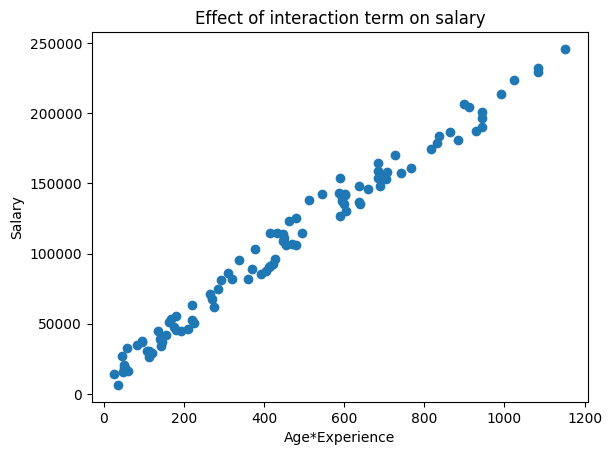

In [ ]:
plt.scatter(df['Age']*df['Experience'], df['Salary'])

plt.xlabel('Age*Experience')
plt.ylabel('Salary')
plt.title("Effect of interaction term on salary")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)


data = {
    'Age': np.random.randint(20, 60, 100),        # Feature
    'Salary': np.random.randint(30000, 120000, 100)  # Target
}

df = pd.DataFrame(data)
print(df)

    Age  Salary
0    58  119135
1    48   65222
2    34  107373
3    27  109575
4    40  114651
..  ...     ...
95   28   97863
96   27   82083
97   31   95733
98   53  119045
99   52   64698

[100 rows x 2 columns]


In [ ]:
def evaluate_model(X, y, model_name):


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")

    return model, X_test, y_test, y_pred

In [ ]:
X = df[['Age']]
y = df['Salary']

model_linear, X_test_linear, y_test_linear, y_pred_linear = evaluate_model(
    X, y, "Linear Model"
)


Linear Model
Mean Squared Error: 732034274.28
R² Score: -0.08


In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)

polynomial_features = poly.fit_transform(df[['Age']])

feature_names = ['Age', 'Age^2']
polynomial_df = pd.DataFrame(polynomial_features, columns=feature_names)

polynomial_df['Salary'] = df['Salary']

print("\nPolynomial Features Data:")
print(polynomial_df.head())



Polynomial Features Data:
    Age   Age^2  Salary
0  58.0  3364.0  119135
1  48.0  2304.0   65222
2  34.0  1156.0  107373
3  27.0   729.0  109575
4  40.0  1600.0  114651


In [ ]:
X_poly = polynomial_df[['Age', 'Age^2']]
y_poly = polynomial_df['Salary']

model_poly, X_test_poly, y_test_poly, y_pred_poly = evaluate_model(
    X_poly, y_poly, "Polynomial Model"
)


Polynomial Model
Mean Squared Error: 805036913.63
R² Score: -0.19


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


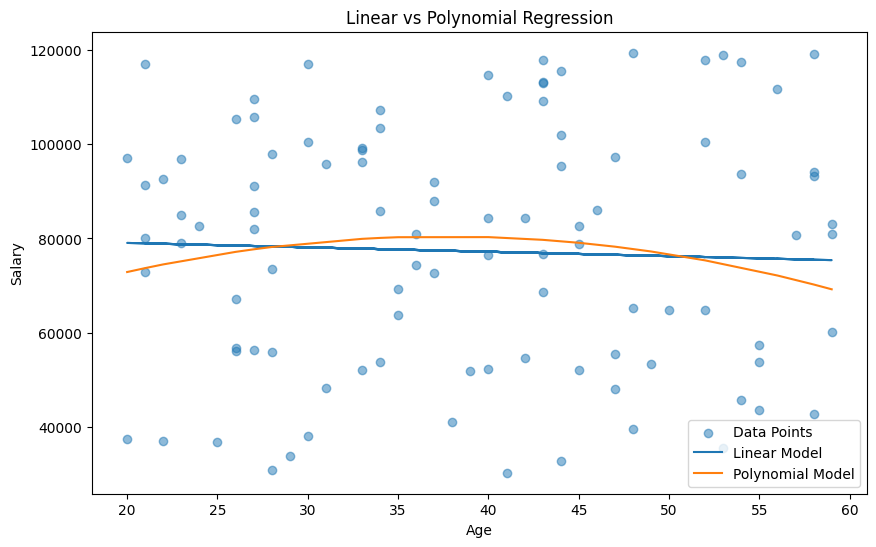

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Age'], df['Salary'], alpha=0.5, label='Data Points')

plt.plot(X_test_linear, y_pred_linear, label='Linear Model')

X_test_poly_sorted = np.sort(X_test_poly, axis=0)

y_pred_poly_sorted = model_poly.predict(X_test_poly_sorted)

plt.plot(X_test_poly_sorted[:, 0], y_pred_poly_sorted, label='Polynomial Model')

plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Linear vs Polynomial Regression')

plt.legend()

plt.show()